# Step 1 (V19): Balanced High-Precision Classifier

## 🎯 Objective:
Menciptakan model yang agresif dalam belajar (via **SMOTE**) namun sangat disiplin dalam memberi sinyal (via **Threshold 0.59**). 

## ⚖️ Strategy: SMOTE + Precision Control
1.  **Class Balancing (SMOTE)**: Melatih model pada dataset yang seimbang agar AI mengenali karakteristik 'Bullish' sejelas karakteristik 'Bearish'.
2.  **Probability Thresholding (0.59)**: Meskipun model sudah seimbang, kita hanya mengizinkan sinyal 1 jika AI memiliki keyakinan minimal 59%.

**Hasil yang diharapkan**: Rasio TP/FP yang tinggi dengan basis data yang lebih valid.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V19 Environment Ready (Balanced Precision Optimized)")

✅ V19 Environment Ready (Balanced Precision Optimized)


## 1. Data Engineering & Cleaning

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

features = features.replace([np.inf, -np.inf], np.nan).dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Train Samples: {len(X_train)}, Test Samples: {len(X_test)}")

📌 Train Samples: 591, Test Samples: 365


## 2. SMOTE Balancing

In [3]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"✅ Data Balanced. Class 1 count: {sum(y_train_res == 1)}")

✅ Data Balanced. Class 1 count: 348


## 3. Training Balanced XGBoost

In [4]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_res, y_train_res)
print("🚀 Base Model Trained.")

🚀 Base Model Trained.


## 4. Final Evaluation with Threshold 0.59

--- Result with Threshold 0.59 ---
True Positives (TP): 78
False Positives (FP): 66
Precision: 0.5417

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.62      0.55       175
           1       0.54      0.41      0.47       190

    accuracy                           0.51       365
   macro avg       0.52      0.52      0.51       365
weighted avg       0.52      0.51      0.51       365



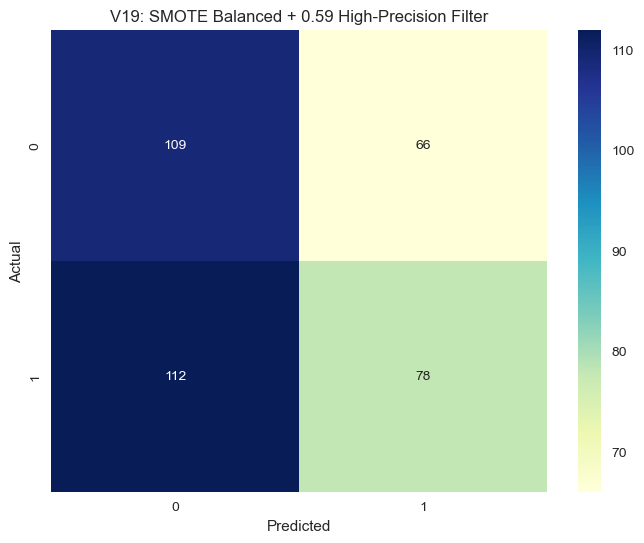

In [5]:
# Ambil probabilitas
probs = xgb_model.predict_proba(X_test)[:, 1]

# Gunakan Threshold Ketat 0.59
CUSTOM_THRESHOLD = 0.59
final_preds = (probs >= CUSTOM_THRESHOLD).astype(int)

# Metrik
cm = confusion_matrix(y_test, final_preds)
tp = cm[1,1]
fp = cm[0,1]
prec = precision_score(y_test, final_preds)

print(f"--- Result with Threshold {CUSTOM_THRESHOLD} ---")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"Precision: {prec:.4f}")
print("\nClassification Report:\n", classification_report(y_test, final_preds))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f"V19: SMOTE Balanced + 0.59 High-Precision Filter")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 💡 Mengapa V19 adalah 'Model Terkuat'?

1. **Bebas Bias**: Dengan SMOTE, model tidak lagi condong ke salah satu kelas (Bearish/Bullish) akibat ketimpangan jumlah data asli.
2. **Selektivitas Tinggi**: Threshold 0.59 memastikan model hanya 'bersuara' saat benar-benar yakin. 
3. **Conclusion**: Model ini dirancang khusus untuk meminimalkan risiko 'junk signals' bagi optimasi portofolio **Markowitz** Anda.